## INSID3-Instance — recursive coarse-to-fine discovery

A breadth-first, batched cascade built on the [refinement idea](insid3_iterative_refinement.ipynb):

> Keep **splitting and re-embedding** every branch until it **re-identifies the exemplar** —
> yielding the exact crop + foreground mask of each instance. Only leaves are returned.

Per crop (one batched DINOv3 forward per BFS level):
1. Re-embed, **gate by cosine** to the exemplar bank → foreground.
2. **Connected components** propose tighter crops. ≥2 components → zoom into each. A single
   component whose bbox does *not* fill the crop → zoom tighter. A component that **fills the
   crop** → converged (no tighter crop extractable).
3. A converged crop becomes a **leaf** iff its **CLS token** re-identifies the exemplar
   (`cos(CLS_crop, CLS_exemplar) ≥ cls_threshold`); a converged-but-rejected large crop is a
   seamless clump → watershed-split fallback.

Different instances zoom to different depths — there is **no early area-based stop**. A pair of
touching fragments is one component at the scene scale; once it gets its own crop the seam
spans enough patches to become two components, so zoom separates what a flat pass cannot.

`models/insid3/cascade.py` · `discover_instances(...) -> (list[DiscoveredInstance], CascadeStats)`,
masks in **original** image coordinates.

> Requires gated DINOv3 weights (`HF_ACCESS_TOKEN`). Per-crop re-embedding is the cost — it is
> batched per level; watch `stats.n_embeds` / `stats.level_sizes`. GPU recommended.

## 0 · Setup + load coral image and exemplar

In [1]:
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")               # silence sklearn connectivity / tqdm spam
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()                # silence "channel dimension ambiguous"

ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)

import numpy as np, torch, cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import patches as mpatches
from collections import Counter
from dotenv import load_dotenv
load_dotenv(ROOT / ".env"); plt.rcParams["figure.dpi"] = 110

DATA = ROOT.parent / "backend" / "data" / "datasets" / "Global Search Dataset"
coco = json.load(open(DATA / "Global_Search_Dataset_coco.json"))
img_id = Counter(a["image_id"] for a in coco["annotations"]).most_common(1)[0][0]
im = next(x for x in coco["images"] if x["id"] == img_id)
image = cv2.cvtColor(cv2.imread(str(DATA / "images" / im["file_name"])), cv2.COLOR_BGR2RGB)
H, W = image.shape[:2]; sx, sy = W / im["width"], H / im["height"]
CORAL = next(c["id"] for c in coco["categories"] if c["name"] == "Coral Fragment")
anns = [a for a in coco["annotations"] if a["image_id"] == img_id and a["category_id"] == CORAL]
def poly_to_mask(a):
    m = np.zeros((H, W), np.uint8)
    for p in a["segmentation"]:
        q = np.array(p, float).reshape(-1, 2); q[:, 0] *= sx; q[:, 1] *= sy
        cv2.fillPoly(m, [q.astype(np.int32)], 1)
    return m
gt = [m for m in (poly_to_mask(a) for a in anns) if m.sum() > 0]
areas = [m.sum() for m in gt]
random_gt_indices = np.random.choice(np.arange(len(gt), dtype=int), size=2, replace=False)
print(f"Selected gt indices: ", random_gt_indices, random_gt_indices.shape, random_gt_indices.dtype)
positive_masks = [gt[index] for index in random_gt_indices]
print(f"{im['file_name']}  {W}x{H}  |  {len(gt)} GT fragments; exemplar area = {int(areas[len(areas)//2])} px")

def rand_cmap(n):
    rng = np.random.default_rng(3); c = rng.random((max(n,1)+1,3)); c[0]=0
    return ListedColormap(c)
def overlay(image, labels, alpha=0.55):
    cm = rand_cmap(int(labels.max())); col = cm(labels/max(labels.max(),1))[...,:3]
    out = image.astype(float)/255.0; m = labels>0
    out[m] = (1-alpha)*out[m] + alpha*col[m]; return out

Selected gt indices:  [0 2] (2,) int64
20220309T1430_CBASS_US_Thatch_Ofav_32.5_T1_10-13.JPG  4000x3000  |  4 GT fragments; exemplar area = 345135 px


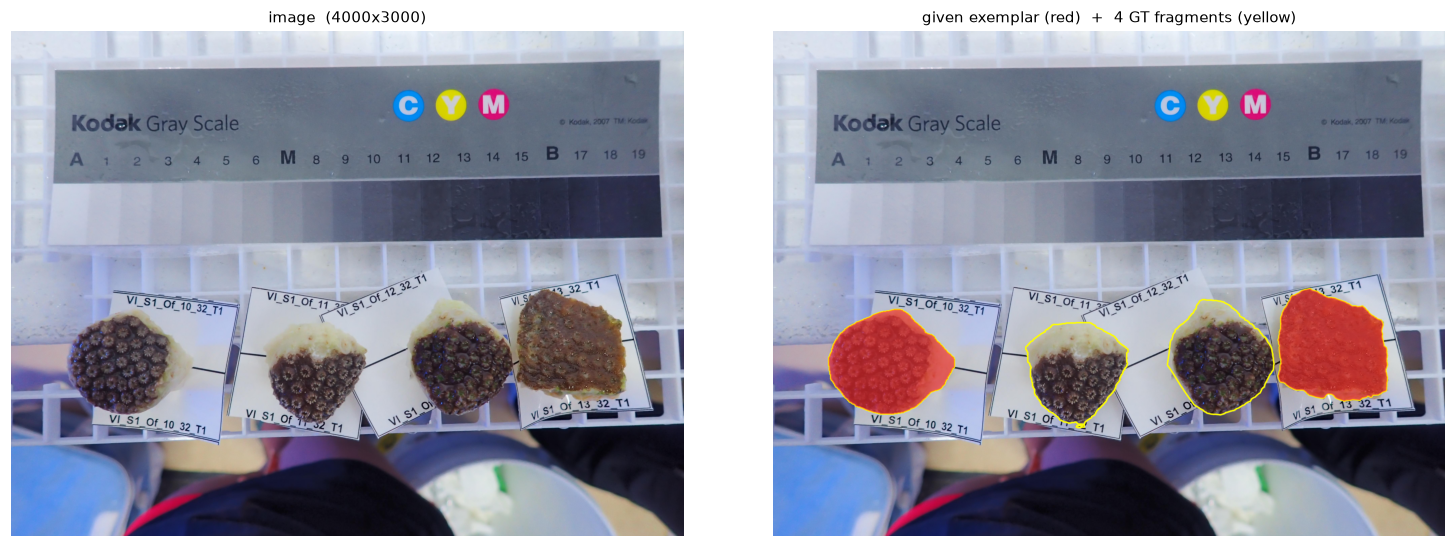

True

In [12]:
# The image and the given exemplar (the single annotated instance the cascade is prompted with).
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(image); ax[0].set_title(f"image  ({W}x{H})", fontsize=10); ax[0].axis("off")
ov = image.copy()
for g_ in gt:                                   # all GT fragments, yellow outline
    c, _ = cv2.findContours((g_ > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(ov, c, -1, (255, 255, 0), max(1, H // 350))
for mask in positive_masks:
    m = mask > 0                       # the one given exemplar, red fill
    ov[m] = (0.4 * ov[m] + 0.6 * np.array([255, 40, 40])).astype(np.uint8)
ax[1].imshow(ov); ax[1].axis("off")
ax[1].set_title(f"given exemplar (red)  +  {len(gt)} GT fragments (yellow)", fontsize=10)
plt.tight_layout(); plt.show()

cv2.imwrite(str(ROOT / "notebooks" / "one_mask.png"), positive_masks[0] * 255)

## 1 · Run the recursive cascade

In [3]:
import time
from sklearn.decomposition import PCA
from iquana_toolbox.ai.backbones.dinov3 import DINOv3Backbone, DEFAULT_DINOV3_MODEL
from models.insid3 import cascade
from models.insid3.pipeline import InSID3Params

backbone = DINOv3Backbone(model_id=DEFAULT_DINOV3_MODEL, image_size=1024, token=os.getenv("HF_ACCESS_TOKEN"))
params = InSID3Params(gate_threshold=0.45, cluster_tau=0.18, marker_mode="hybrid")

# An `observer` records every processed crop so we can visualize each iteration + its PCA below.
# border_mode="proto" refines each leaf's border with the optimal per-instance threshold (§3b).
CLS_THRESHOLD = 0.5   # calibrate from the score histogram (cell 4) + exemplar-recovery (cell 5)
TRACE = []
def _observer(info):
    feat = info["feat"]; Hp, Wp, D = feat.shape
    rgb = PCA(3).fit_transform(feat.reshape(-1, D).cpu().numpy()).reshape(Hp, Wp, 3)
    rgb = (rgb - rgb.min()) / (np.ptp(rgb) + 1e-8)
    TRACE.append(dict(level=info["level"], depth=info["depth"], box=info["box"],
                      decision=info["decision"], n=info["n_components"], cls=info["cls_score"],
                      pca=rgb, fg=info["fg"].astype(bool), comp=info["comp_labels"].astype(np.int16)))

t0 = time.time()
instances, stats = cascade.discover_instances(
    backbone, image, positive_masks, params=params,
    max_depth=8, min_crop=64, pad_frac=0.08, shrink_stop=0.9,
    cls_threshold=CLS_THRESHOLD, clump_area_factor=1.5,
    min_instance_area=int(0.05 * areas[len(areas)//2]),
    embed_batch_size=8, max_total_embeds=512, split_mode="watershed", prototype_mode="cluster", n_prototypes=9,
    border_mode="otsu", observer=_observer,
)
print(f"discovered {len(instances)} instances  (GT has {len(gt)})  in {time.time()-t0:.1f}s")
print(f"stats: embeds={stats.n_embeds}/512  max_depth={stats.max_depth}  "
      f"leaves={stats.leaves}  discarded={stats.discarded}")
print(f"BFS level sizes (crops embedded per level): {stats.level_sizes}")

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5531.45it/s]


discovered 3 instances  (GT has 4)  in 36.6s
stats: embeds=76/512  max_depth=7  leaves=3  discarded=0
BFS level sizes (crops embedded per level): [1, 1, 5, 9, 9, 9, 10, 31]


## 1b · What it does at each iteration (per-crop trace + PCA)

Every crop the cascade embeds is recorded by the `observer`. For each BFS level we show, per
crop: the **crop with its gated foreground** outlined, the **DINOv3 features as PCA-RGB** (how
the representation sharpens as we zoom), and the **connected components** (the split proposal).
The title gives the depth, the decision (`split` / `zoom` / `leaf` / `clump-split` /
`leaf-cap`), and the CLS re-identification score when converged.

In [4]:
from collections import Counter

def fg_contour(crop, fg):
    h, w = crop.shape[:2]
    m = cv2.resize(fg.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = crop.copy(); cv2.drawContours(out, cnts, -1, (0, 255, 0), max(1, h // 150)); return out

def show_level(level, maxn=8):
    nodes = [t for t in TRACE if t["level"] == level][:maxn]
    if not nodes:
        return
    n = len(nodes)
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 7.6), squeeze=False)
    for j, t in enumerate(nodes):
        y0, y1, x0, x1 = t["box"]; crop = image[y0:y1, x0:x1]
        title = f"d{t['depth']} {t['decision']}" + ("" if t["cls"] is None else f" cls={t['cls']:.2f}")
        ax[0, j].imshow(fg_contour(crop, t["fg"])); ax[0, j].set_title(title, fontsize=8)
        ax[1, j].imshow(t["pca"])
        ax[2, j].imshow(t["comp"], cmap="tab20", interpolation="nearest")
        for i in range(3): ax[i, j].axis("off")
    for i, lab in enumerate(["crop + foreground", "DINOv3 PCA-RGB", "components"]):
        ax[i, 0].set_title(f"[{lab}]\n" + ax[i, 0].get_title(), fontsize=8)
    total = sum(t["level"] == level for t in TRACE)
    plt.suptitle(f"BFS level {level}  —  {total} crops embedded", fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

print("decisions per BFS level:")
for lvl in sorted({t["level"] for t in TRACE}):
    print(f"  level {lvl}: {dict(Counter(t['decision'] for t in TRACE if t['level'] == lvl))}")

decisions per BFS level:
  level 0: {'zoom': 1}
  level 1: {'split': 1}
  level 2: {'leaf': 3, 'split': 1, 'empty': 1}
  level 3: {'split': 1, 'empty': 8}
  level 4: {'empty': 8, 'split': 1}
  level 5: {'empty': 8, 'split': 1}
  level 6: {'empty': 9, 'split': 1}
  level 7: {'empty': 31}


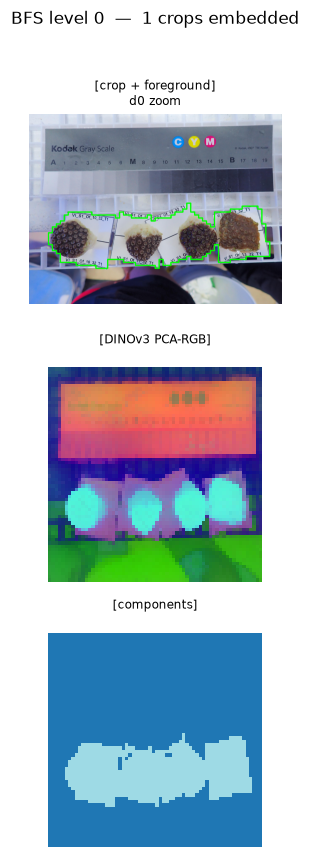

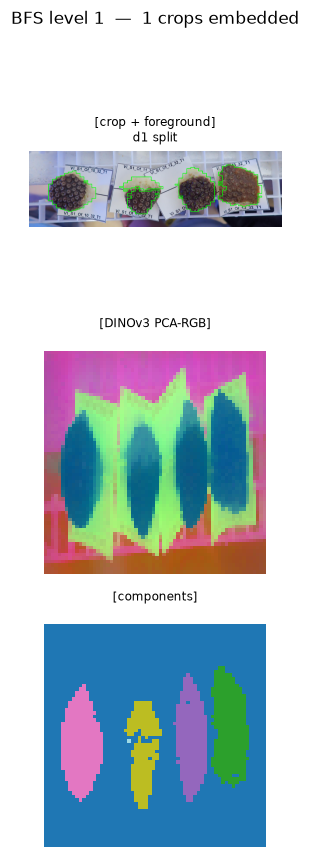

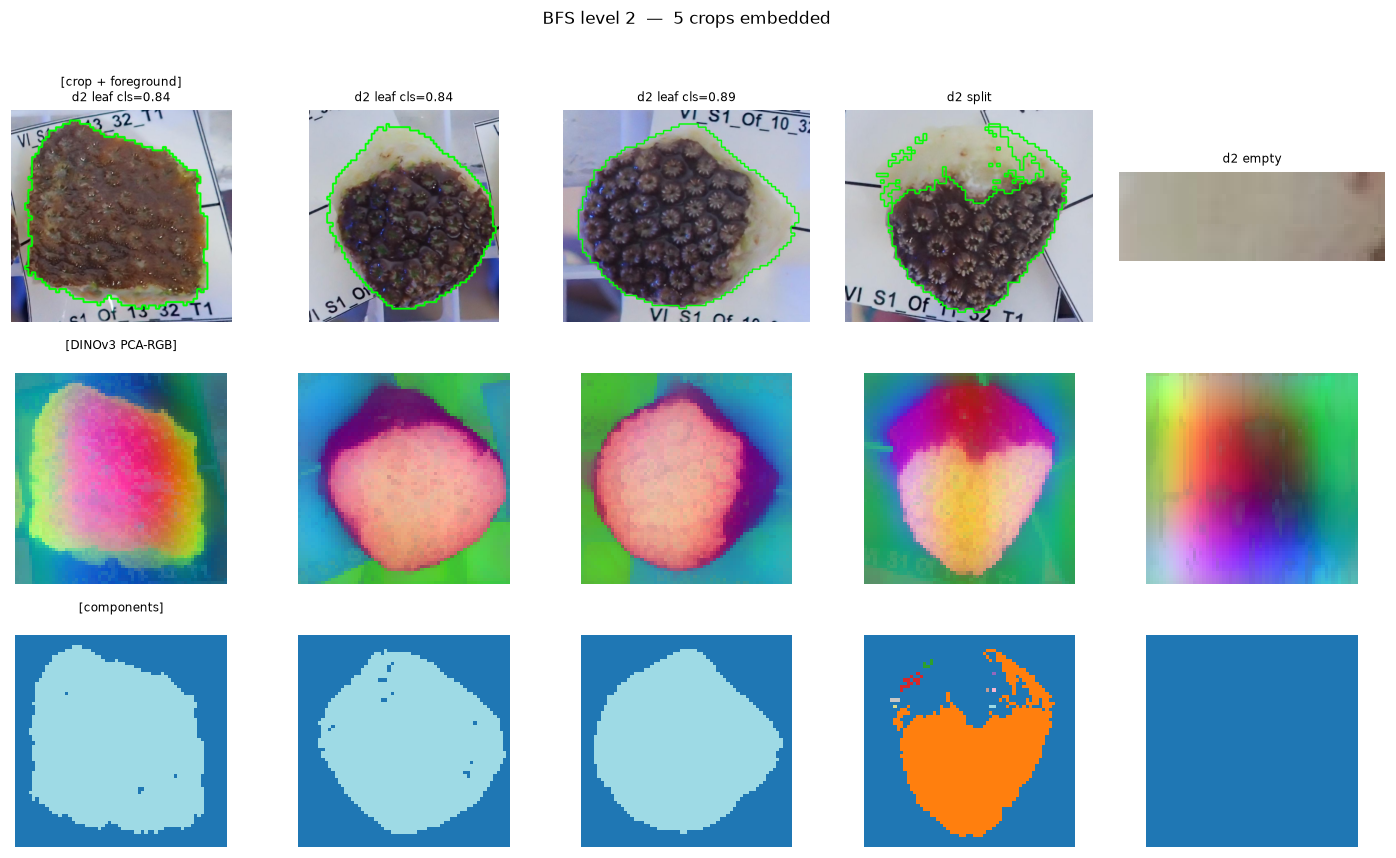

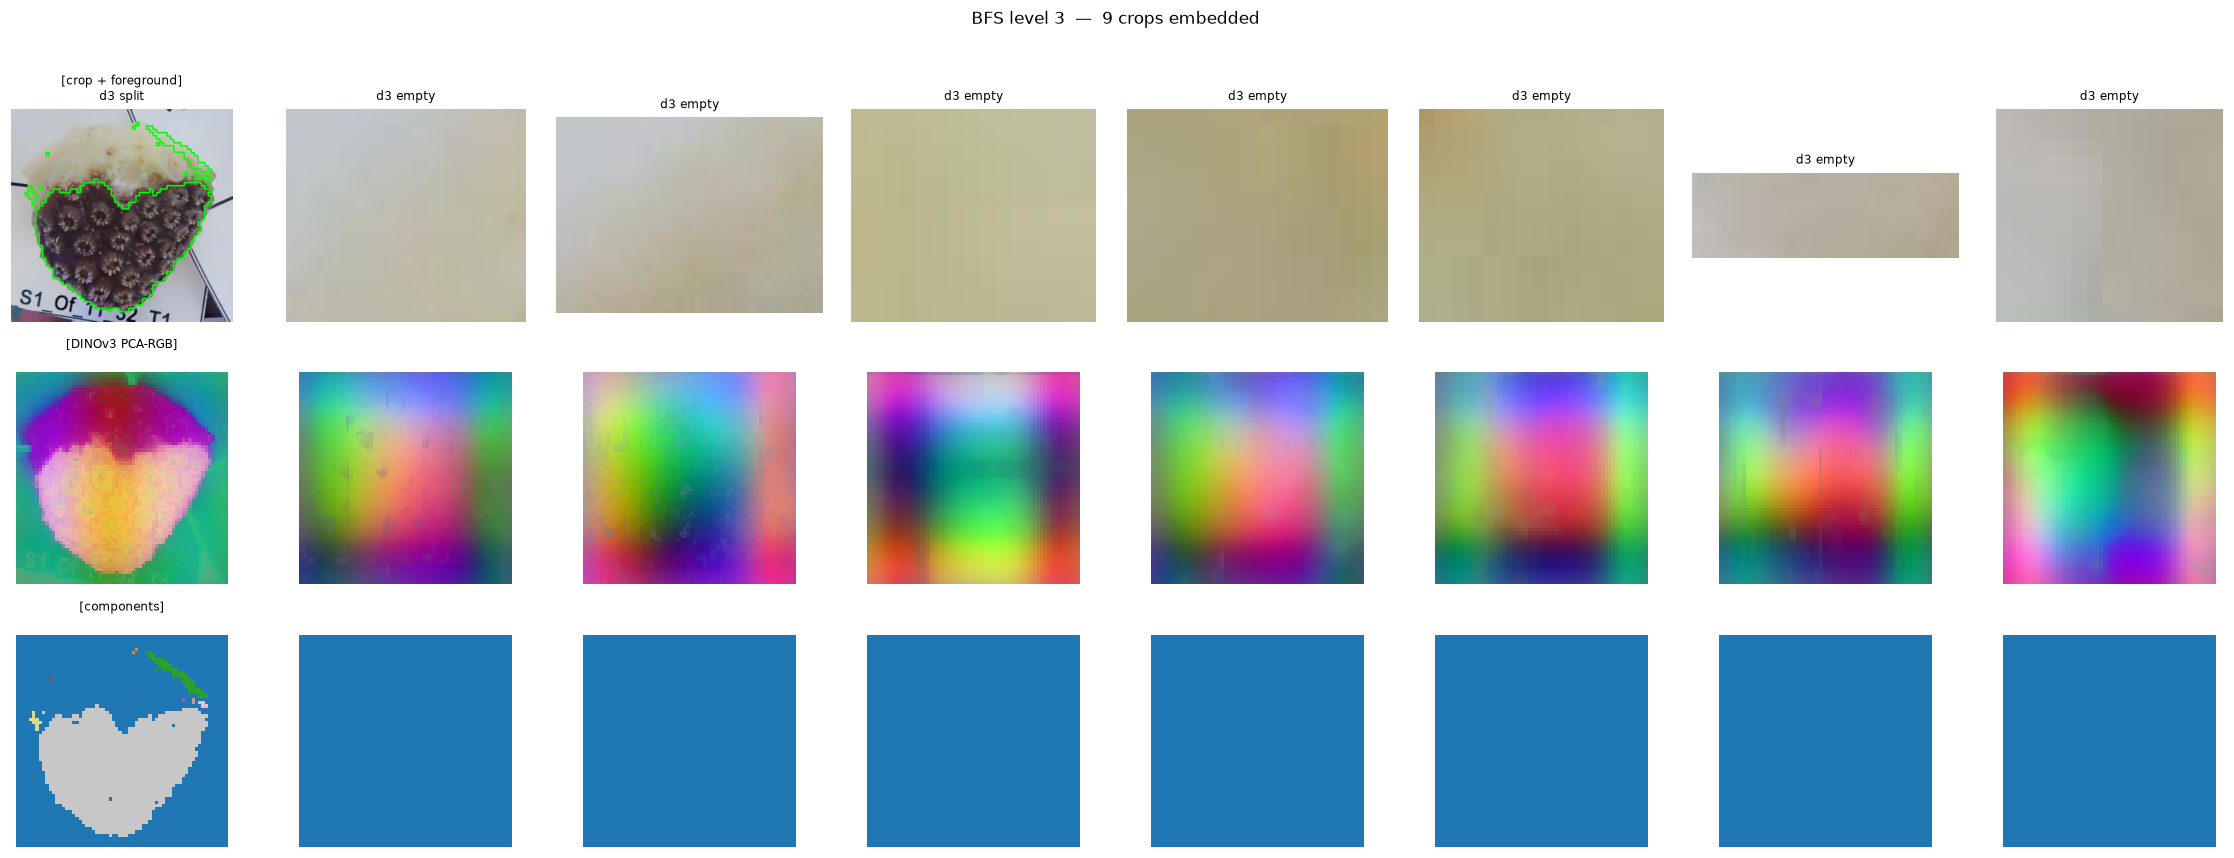

In [5]:
# Walk the first few BFS levels. Watch the PCA-RGB sharpen and the foreground tighten as the
# crop zooms in; the components row shows where the cascade decides to split.
for lvl in sorted({t["level"] for t in TRACE})[:4]:
    show_level(lvl, maxn=8)

## 2 · All discovered instances + the crops that isolated them

Each instance is colored; its dashed box is the crop the recursion used to isolate it (deeper = tighter zoom). This is the per-instance crop + mask the loop converges to.

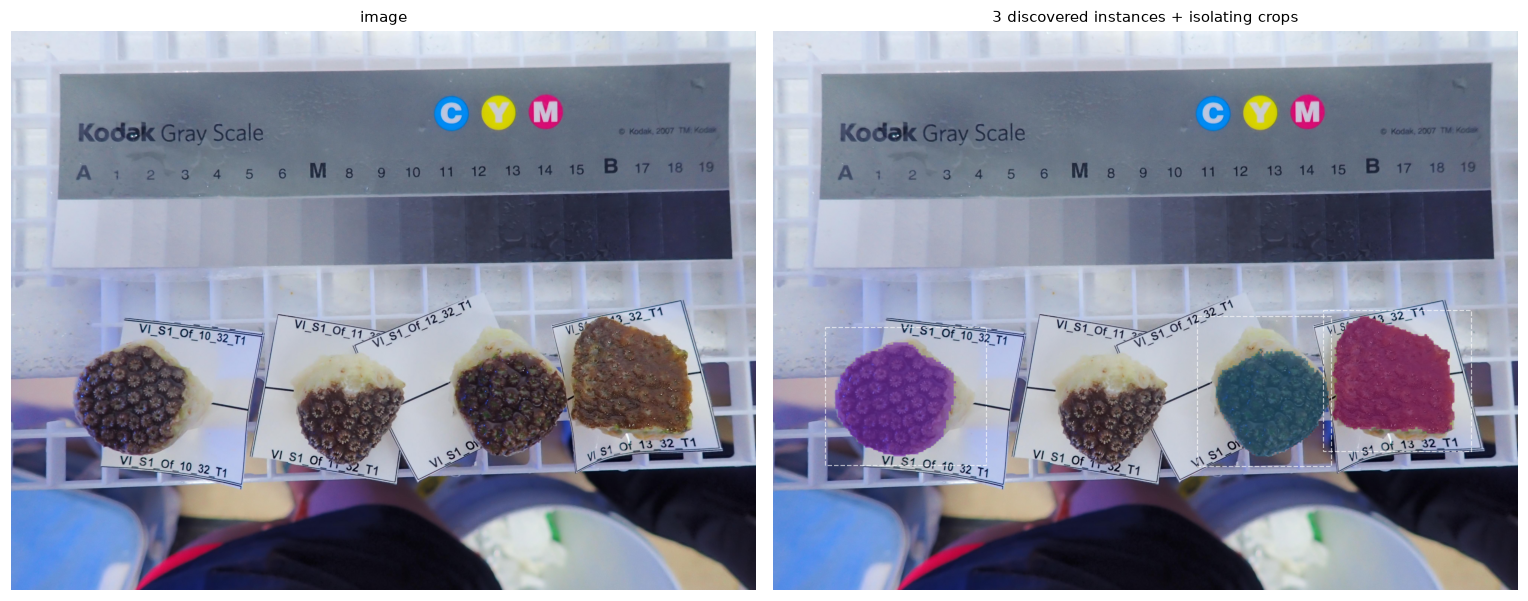

In [6]:
inst_label = np.zeros((H, W), np.int32)
for i, d in enumerate(sorted(instances, key=lambda d: -int(d.mask.sum())), 1):
    inst_label[d.mask > 0] = i

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(image); ax[0].set_title("image", fontsize=10); ax[0].axis("off")
ax[1].imshow(overlay(image, inst_label))
for d in instances:
    y0, y1, x0, x1 = d.box
    ax[1].add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                    edgecolor="white", lw=0.8, ls="--", alpha=0.6))
ax[1].set_title(f"{len(instances)} discovered instances + isolating crops", fontsize=10); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 3 · Example leaves — exact crop + foreground mask per instance

The deliverable: for each discovered instance, the tight image crop and its mask, plus the re-identification score (mean similarity of its patches to the exemplar bank).

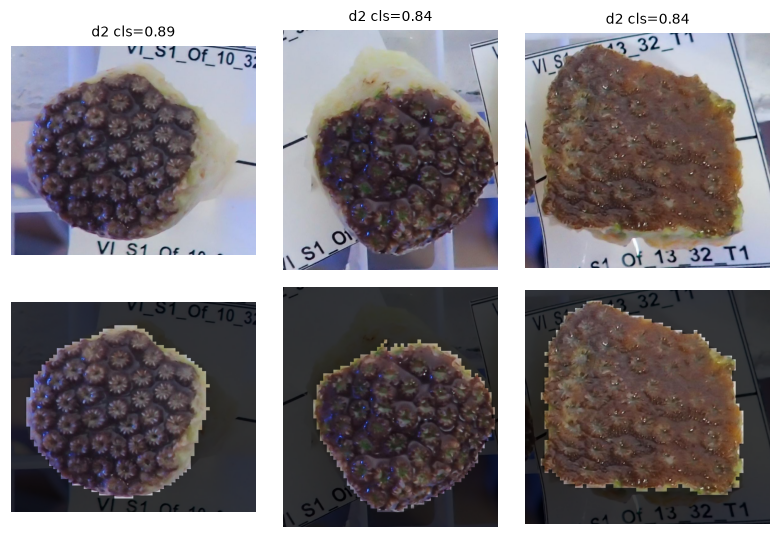

In [7]:
show_n = min(8, len(instances))
picks = sorted(instances, key=lambda d: -d.cls_score)[:show_n]
fig, axes = plt.subplots(2, show_n, figsize=(2.4*show_n, 5))
axes = np.atleast_2d(axes)
for j, d in enumerate(picks):
    y0, y1, x0, x1 = d.box
    crop = image[y0:y1, x0:x1]; m = d.mask[y0:y1, x0:x1]
    axes[0, j].imshow(crop); axes[0, j].axis("off")
    axes[0, j].set_title(f"d{d.depth} cls={d.cls_score:.2f}", fontsize=9)
    cut = crop.copy(); cut[m == 0] = (cut[m == 0] * 0.25).astype(np.uint8)
    axes[1, j].imshow(cut); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

## 3b · Border refinement — optimal threshold vs static vs Otsu

A converged crop's mask is only as good as its threshold. Instead of the static gate threshold
we pick, per instance, the threshold that **maximizes `cos(prototype(mask), exemplar)`** — found
in one sorted cumulative-sum pass (every threshold evaluated at once, no iteration). For each
leaf below: the similarity-to-prototype map, the objective `J(τ)` with the chosen `proto τ*`
(green), the static threshold (red) and Otsu (blue), and the three resulting borders overlaid.

Read the borders critically: `proto` maximizes purity and can shrink to the instance core on
*heterogeneous* fragments; `otsu` separates the instance/background modes and tends to keep the
full extent. Pick per your IoU against GT.

## 4 · Where did recursion help? Depth & score distribution

Instances emitted at depth ≥ 1 are ones the zoom-in separated — they were merged into a parent region at coarser resolution and only split after re-embedding.

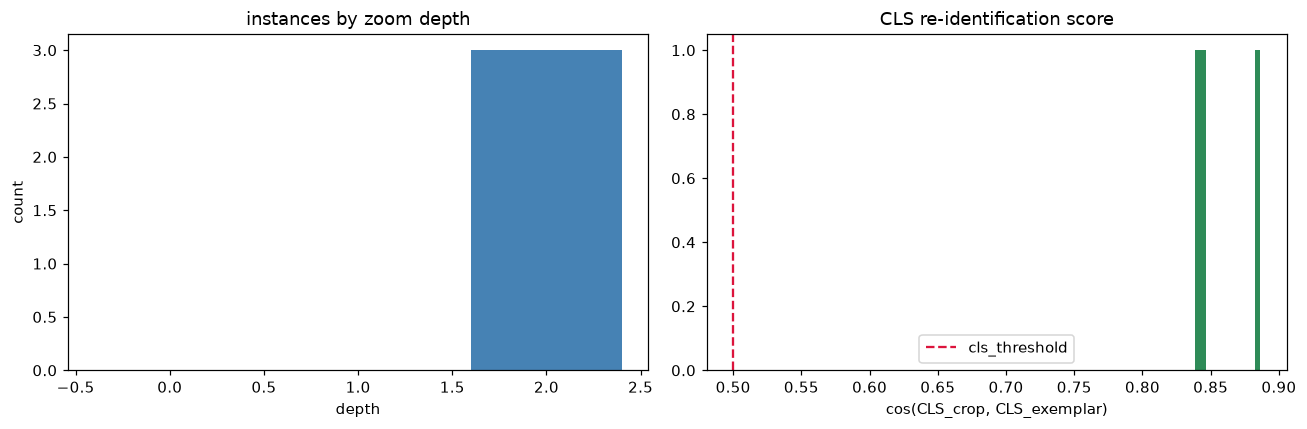

instances per depth: {2: 3}


In [8]:
depths = [d.depth for d in instances]; scores = [d.cls_score for d in instances]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(depths, bins=range(0, max(depths)+2), align="left", rwidth=0.8, color="steelblue")
ax[0].set_title("instances by zoom depth"); ax[0].set_xlabel("depth"); ax[0].set_ylabel("count")
ax[1].hist(scores, bins=12, color="seagreen")
ax[1].axvline(CLS_THRESHOLD, color="crimson", ls="--", label="cls_threshold")
ax[1].set_title("CLS re-identification score"); ax[1].set_xlabel("cos(CLS_crop, CLS_exemplar)"); ax[1].legend()
plt.tight_layout(); plt.show()
from collections import Counter as C
print("instances per depth:", dict(sorted(C(depths).items())))

## 5 · Cascade vs single pass

How many more instances does recursion recover over one flat `pipeline.run`?

single pass : 9 instances
cascade     : 3 instances
ground truth: 4 fragments


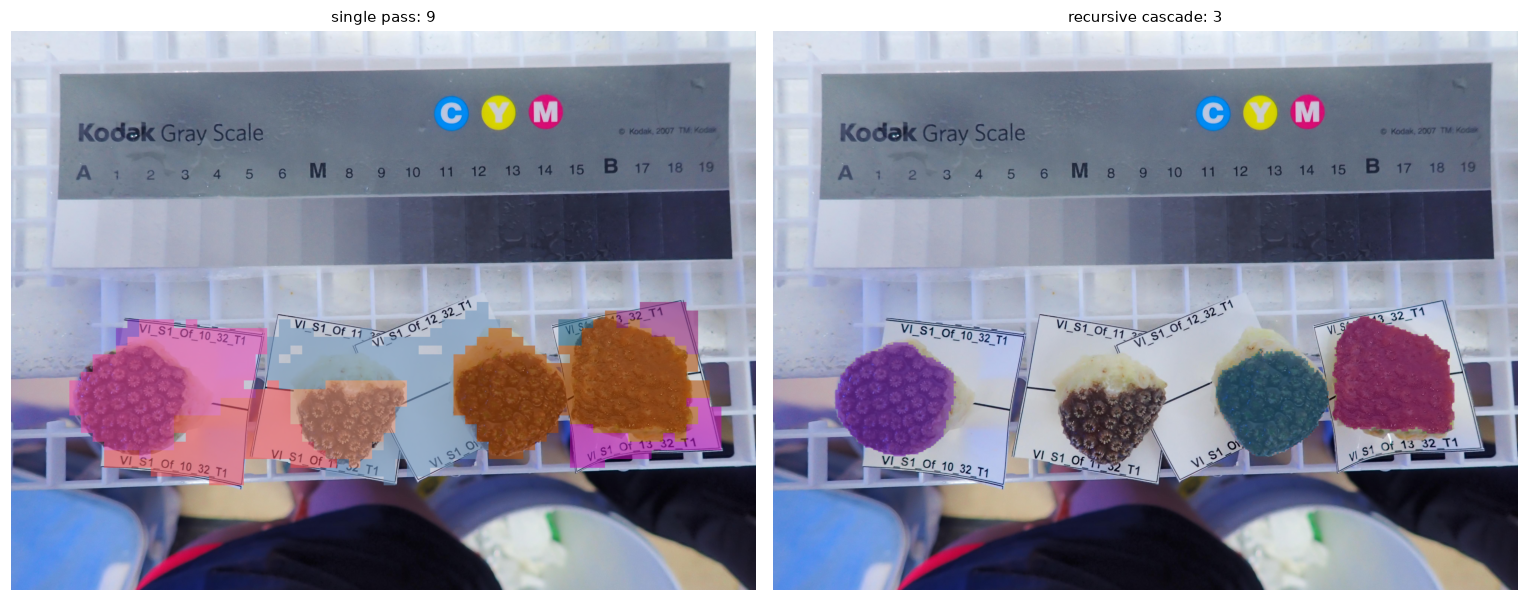

In [9]:
from models.insid3 import pipeline
flat = pipeline.run(backbone, image, positive_masks, None, params)
print(f"single pass : {flat.instance_masks.shape[0]} instances")
print(f"cascade     : {len(instances)} instances")
print(f"ground truth: {len(gt)} fragments")

flat_label = np.zeros((H, W), np.int32)
for i, m in enumerate(flat.instance_masks, 1): flat_label[m > 0] = i
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(overlay(image, flat_label))
ax[0].set_title(f"single pass: {flat.instance_masks.shape[0]}", fontsize=10); ax[0].axis("off")
ax[1].imshow(overlay(image, inst_label))
ax[1].set_title(f"recursive cascade: {len(instances)}", fontsize=10); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 6 · Notes & caveats

**Convergence = a connected-components fixed point.** A branch zooms while a *strictly tighter*
component-bbox crop exists; it converges when the only component fills its crop. Because the
bbox is rectangular like the crop, `bbox_fill` can genuinely reach ~0.95 (unlike foreground
*area* coverage, which is shape-limited). Connected components is the primary splitter — a
sub-patch seam becomes a real pixel gap (two components) once zoomed.

**Acceptance = the CLS token.** A converged crop is *identified* (single instance vs seamless
clump vs background) by `cos(CLS_crop, CLS_exemplar)`. Calibrate `cls_threshold` from the
score histogram (cell 4): pick the valley between the exemplar-like leaves and the rejects. A
rejected *large* crop (> `clump_area_factor` × exemplar) falls back to a watershed split.

**No early stopping.** Unlike the previous design (which stopped at exemplar-sized components
without zooming), every branch zooms until the fixed point. Small / crowded instances iterate
longer — that is intended. Bounds are pure safety: `max_depth`, `min_crop` (resolution floor —
re-embedding below the native grid only interpolates), and `max_total_embeds`.

**Cost & batching.** One DINOv3 forward per BFS *level* (`embed_batch_size` crops per chunk),
not per node — see `stats.level_sizes`. GPU recommended for crowded scenes.

**Two real-data gotchas seen in testing.**
- *Uniform crops + standardization.* A fully-converged crop that is nearly one flat instance
  has tiny per-dim variance; `InSID3Params(standardize=True)` then amplifies noise. Real
  DINOv3 features are textured so this is mild, but set `standardize=False` if a single
  instance fragments at the deepest zoom.
- *Exemplar-edge leakage.* The cosine gate uses *max* similarity to exemplar patches; if the
  exemplar mask includes background at its edge, the gate over-fires. Keep the exemplar mask
  tight (erode by a patch).

**Coordinates.** `DiscoveredInstance.mask` is in original-image coordinates; `.box` is the
crop that isolated it; `.cls_score` is the re-identification similarity.

## 7 · Does it work *across* images? (in-context)

The true in-context test: keep the exemplar from **this** image but discover the same concept in
a **different target** image. Pass `exemplar_image=<reference>` — the bank is built from the
reference, and *every* crop of the target (including the root) is gated against it.

> [!warning] Cross-image is harder than intra-image.
> DINOv3 cross-image matching carries a **positional bias** (INSID3 Sec. 3.1): features at the
> same location spuriously match across unrelated images. We do **not** correct it yet, so the
> root gate on the full target can over-fire. The object-scale crops at deeper levels mitigate
> it. If the root foreground looks wrong, that bias is the first suspect.

reference: 20220309T1430_CBASS_US_Thatch_Ofav_32.5_T1_10-13.JPG   →   target: 20220309T1430_CBASS_US_Thatch_Ofav_32.5_T1_14-17.JPG  4000x3000  (4 GT fragments)
cross-image: discovered 3 instances (target GT=4) in 24.4s  embeds=164  levels=[1, 7, 24, 28, 18, 19, 22, 22, 22]


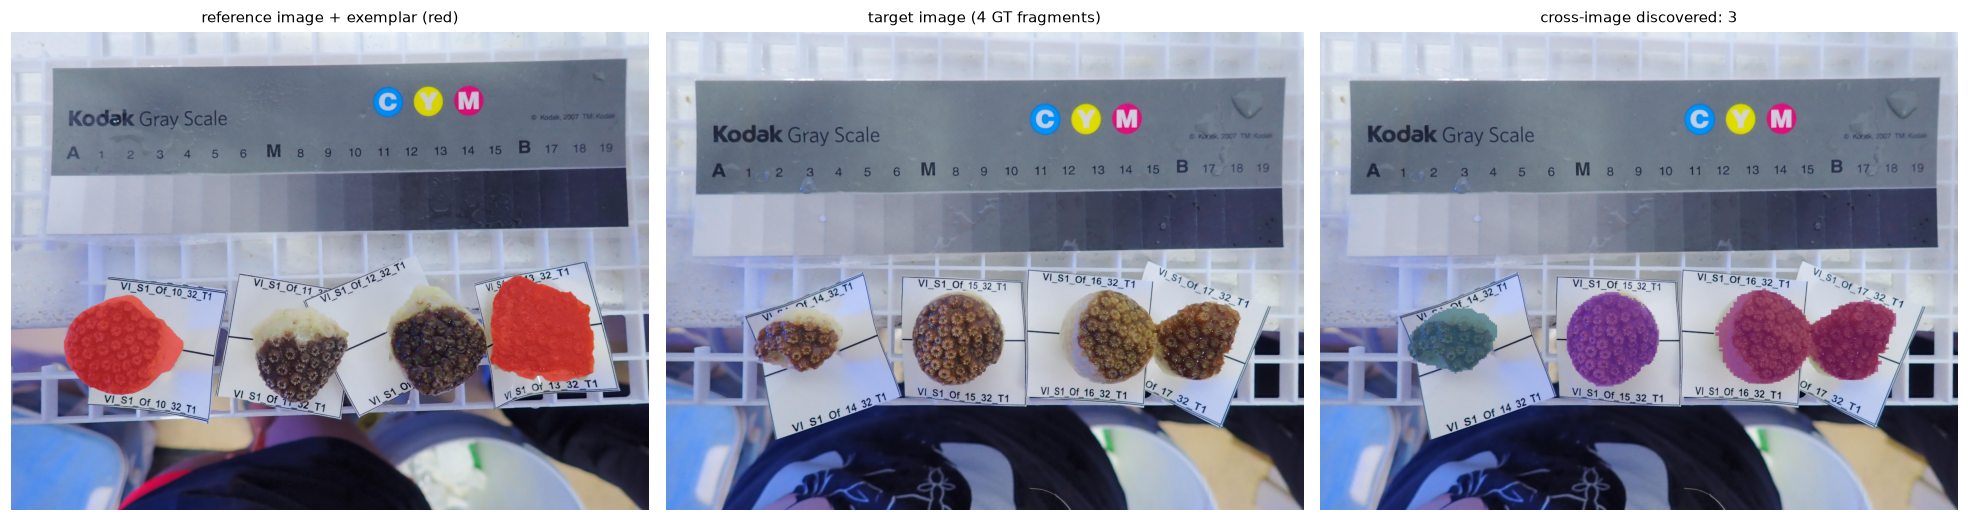

In [10]:
# Pick a DIFFERENT image (with coral) as the target; the exemplar stays from the first image.
other_ids = [i["id"] for i in coco["images"]
             if i["id"] != img_id
             and any(a["image_id"] == i["id"] and a["category_id"] == CORAL for a in coco["annotations"])]
img_id2 = other_ids[0]
im2 = next(x for x in coco["images"] if x["id"] == img_id2)
target = cv2.cvtColor(cv2.imread(str(DATA / "images" / im2["file_name"])), cv2.COLOR_BGR2RGB)
H2, W2 = target.shape[:2]; sx2, sy2 = W2 / im2["width"], H2 / im2["height"]
anns2 = [a for a in coco["annotations"] if a["image_id"] == img_id2 and a["category_id"] == CORAL]
def poly_to_mask2(a):
    m = np.zeros((H2, W2), np.uint8)
    for p in a["segmentation"]:
        q = np.array(p, float).reshape(-1, 2); q[:, 0] *= sx2; q[:, 1] *= sy2
        cv2.fillPoly(m, [q.astype(np.int32)], 1)
    return m
gt2 = [m for m in (poly_to_mask2(a) for a in anns2) if m.sum() > 0]
print(f"reference: {im['file_name']}   →   target: {im2['file_name']}  {W2}x{H2}  ({len(gt2)} GT fragments)")

t0 = time.time()
inst2, stats2 = cascade.discover_instances(
    backbone, target, positive_masks, params=params, exemplar_image=image,
    max_depth=8, min_crop=64, pad_frac=0.08, shrink_stop=0.9, cls_threshold=CLS_THRESHOLD,
    clump_area_factor=1.5, min_instance_area=int(0.05 * areas[len(areas)//2]),
    embed_batch_size=8, max_total_embeds=512, split_mode="watershed", border_mode="otsu",
)
print(f"cross-image: discovered {len(inst2)} instances (target GT={len(gt2)}) in {time.time()-t0:.1f}s  "
      f"embeds={stats2.n_embeds}  levels={stats2.level_sizes}")

lab2 = np.zeros((H2, W2), np.int32)
for i, d in enumerate(sorted(inst2, key=lambda d: -int(d.mask.sum())), 1): lab2[d.mask > 0] = i
ref = image.copy();
for mask in positive_masks:
    mref = mask > 0
    ref[mref] = (0.4 * ref[mref] + 0.6 * np.array([255, 40, 40])).astype(np.uint8)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(ref); ax[0].set_title("reference image + exemplar (red)", fontsize=10); ax[0].axis("off")
ax[1].imshow(target); ax[1].set_title(f"target image ({len(gt2)} GT fragments)", fontsize=10); ax[1].axis("off")
ax[2].imshow(overlay(target, lab2)); ax[2].axis("off")
ax[2].set_title(f"cross-image discovered: {len(inst2)}", fontsize=10)
plt.tight_layout(); plt.show()